In [1]:
# Objectif : Analyse approfondie du meilleur modèle (Logistic Regression)
# Matrice de confusion, courbe ROC, feature importance
# Input    : data/processed/train_fe.csv + test_fe.csv
# Auteur   : Romaric TCHOFFO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve)

train = pd.read_csv("../data/processed/train_fe.csv")
test  = pd.read_csv("../data/processed/test_fe.csv")

X_train = train.drop(columns=["Exited"])
y_train = train["Exited"]
X_test  = test.drop(columns=["Exited"])
y_test  = test["Exited"]

# Réentraîner le meilleur modèle
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("Modèle réentraîné ✓")
print(f"X_test : {X_test.shape}")

Modèle réentraîné ✓
X_test : (3000, 19)


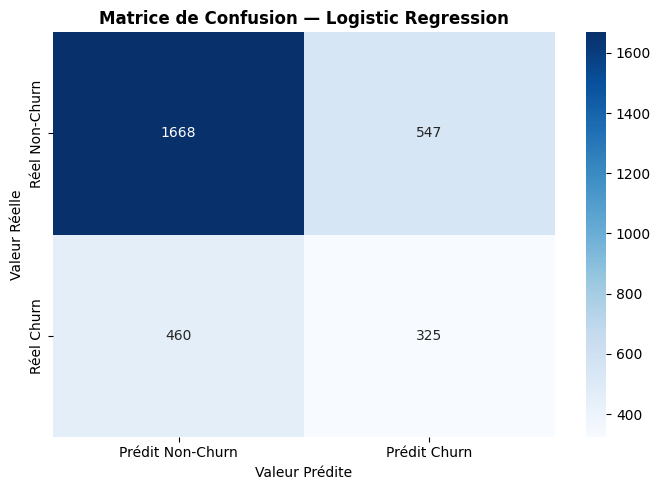

              precision    recall  f1-score   support

   Non-Churn       0.78      0.75      0.77      2215
       Churn       0.37      0.41      0.39       785

    accuracy                           0.66      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.68      0.66      0.67      3000



In [2]:
# Matrice de confusion
# Permet de voir exactement où le modèle se trompe
# Vrais Positifs  (TP) : churners correctement détectés
# Faux Négatifs   (FN) : churners manqués → coûteux pour la banque
# Faux Positifs   (FP) : non-churners classés comme churners
# Vrais Négatifs  (TN) : non-churners correctement identifiés

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit Non-Churn", "Prédit Churn"],
            yticklabels=["Réel Non-Churn",   "Réel Churn"])
ax.set_title("Matrice de Confusion — Logistic Regression", fontweight="bold")
ax.set_ylabel("Valeur Réelle")
ax.set_xlabel("Valeur Prédite")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred,
      target_names=["Non-Churn", "Churn"]))

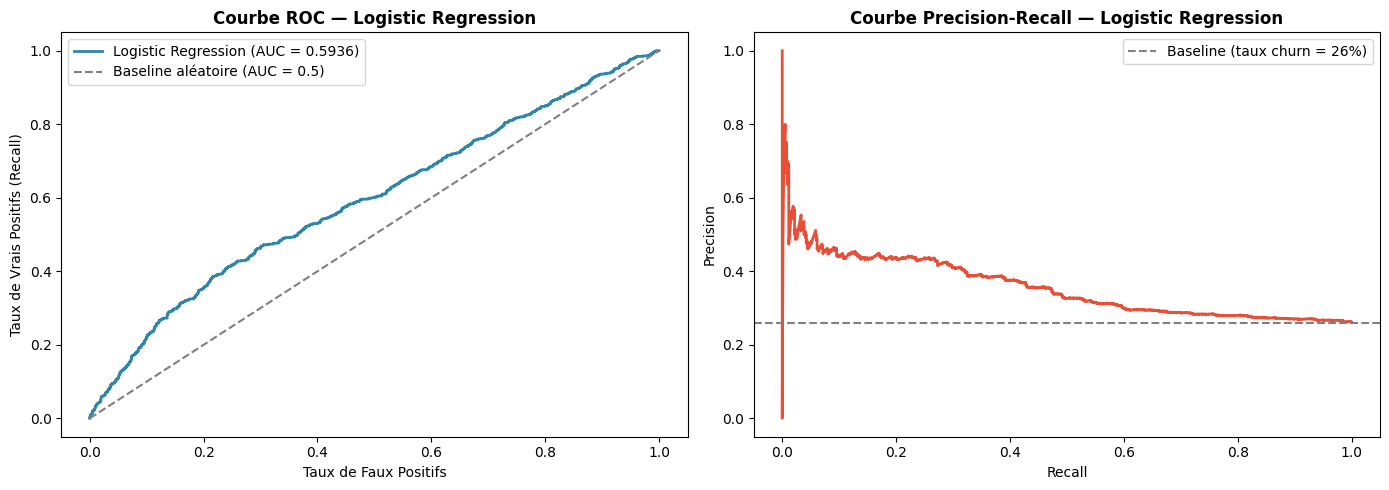

In [4]:
# Courbe ROC — visualise le compromis entre
# Taux de vrais positifs (recall) et taux de faux positifs
# Plus la courbe est proche du coin supérieur gauche → meilleur modèle
# AUC = aire sous la courbe → 1.0 = parfait, 0.5 = aléatoire

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
ax1.plot(fpr, tpr, color="#2E86AB", lw=2, label=f"Logistic Regression (AUC = {auc:.4f})")
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Baseline aléatoire (AUC = 0.5)")
ax1.set_xlabel("Taux de Faux Positifs")
ax1.set_ylabel("Taux de Vrais Positifs (Recall)")
ax1.set_title("Courbe ROC — Logistic Regression", fontweight="bold")
ax1.legend()

# Courbe Precision-Recall
# Plus utile que ROC quand les classes sont déséquilibrées
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(recall_curve, precision_curve, color="#E94F37", lw=2)
ax2.axhline(y=0.26, color="gray", linestyle="--", label="Baseline (taux churn = 26%)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Courbe Precision-Recall — Logistic Regression", fontweight="bold")
ax2.legend()

plt.tight_layout()
plt.show()

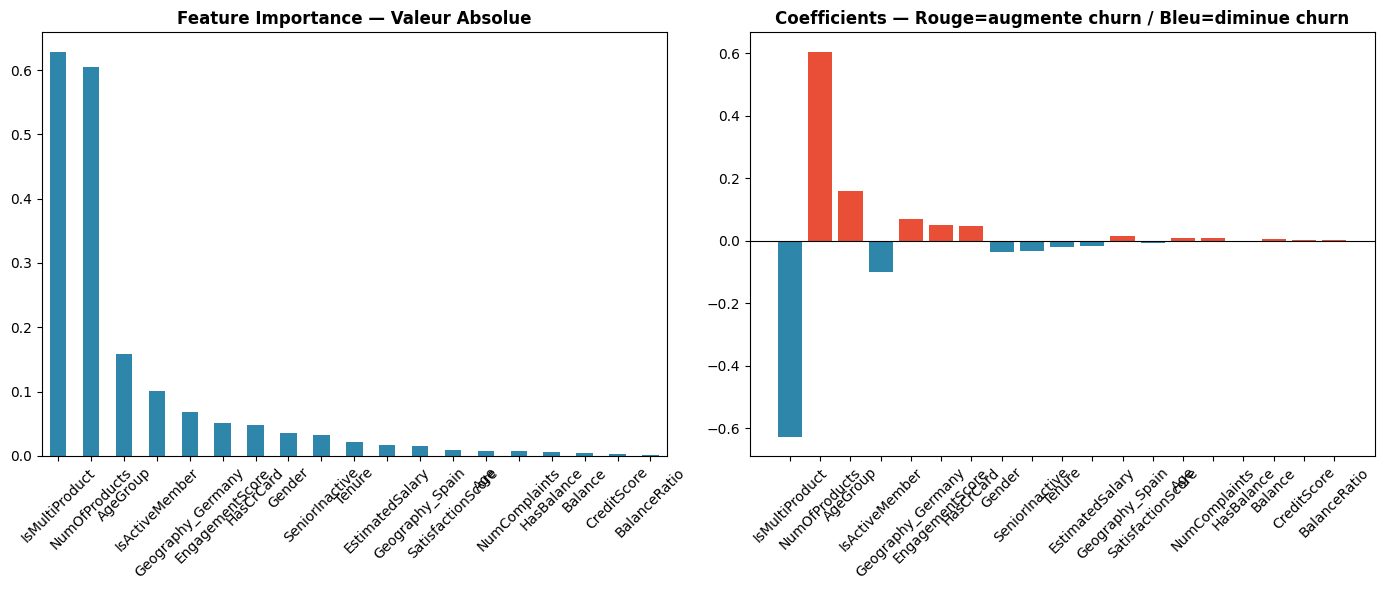


Top 5 features qui augmentent le churn :
              feature  coefficient  importance
5       NumOfProducts     0.605346    0.605346
13           AgeGroup     0.157797    0.157797
11  Geography_Germany     0.068496    0.068496
17    EngagementScore     0.051028    0.051028
6           HasCrCard     0.048093    0.048093

Top 5 features qui diminuent le churn :
           feature  coefficient  importance
16  IsMultiProduct    -0.627369    0.627369
7   IsActiveMember    -0.100309    0.100309
1           Gender    -0.035242    0.035242
18  SeniorInactive    -0.031721    0.031721
3           Tenure    -0.020852    0.020852


In [5]:
# Feature Importance — Logistic Regression
# Les coefficients indiquent l'influence de chaque feature
# Coefficient positif → augmente la probabilité de churn
# Coefficient négatif → diminue la probabilité de churn
# On prend la valeur absolue pour l'importance globale

coefficients = pd.DataFrame({
    "feature"    : X_train.columns,
    "coefficient": lr.coef_[0],
    "importance" : np.abs(lr.coef_[0])
}).sort_values("importance", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Importance absolue
coefficients.plot(x="feature", y="importance", kind="bar",
                  ax=ax1, color="#2E86AB", legend=False)
ax1.set_title("Feature Importance — Valeur Absolue", fontweight="bold")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=45)

# Coefficients avec signe — montre le sens de l'influence
colors = ["#E94F37" if c > 0 else "#2E86AB" for c in coefficients["coefficient"]]
ax2.bar(coefficients["feature"], coefficients["coefficient"], color=colors)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("Coefficients — Rouge=augmente churn / Bleu=diminue churn",
              fontweight="bold")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nTop 5 features qui augmentent le churn :")
print(coefficients[coefficients["coefficient"] > 0].head())
print("\nTop 5 features qui diminuent le churn :")
print(coefficients[coefficients["coefficient"] < 0].head())

In [7]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Sauvegarde du modèle retenu
joblib.dump(lr, "../models/logistic_regression.joblib")

# Sauvegarde du scaler — indispensable pour les nouvelles prédictions
# Sans le scaler on ne peut pas standardiser les nouvelles données
# de la même façon qu'à l'entraînement
joblib.dump(X_train.columns.tolist(), "../models/feature_names.joblib")

print("Modèle sauvegardé → models/logistic_regression.joblib")
print("Features sauvegardées → models/feature_names.joblib")

# Vérification — rechargement et test
lr_loaded = joblib.load("../models/logistic_regression.joblib")
y_pred_test = lr_loaded.predict(X_test)
print(f"\nVérification chargement : {(y_pred_test == y_pred).all()}")

Modèle sauvegardé → models/logistic_regression.joblib
Features sauvegardées → models/feature_names.joblib

Vérification chargement : True


# Conclusions Générales — Model Evaluation ChurnGuard

## Matrice de confusion — Logistic Regression

Vrais Négatifs  (TN) : 1668 → non-churners correctement identifiés
Faux Positifs   (FP) : 547  → non-churners classés comme churners
Faux Négatifs   (FN) : 460  → churners manqués par le modèle
Vrais Positifs  (TP) : 325  → churners correctement détectés

En contexte bancaire, les FN=460 sont les plus coûteux.
Ce sont des clients qui vont partir sans qu'on ait pu les retenir.

## Courbe ROC

AUC = 0.5936 → au-dessus de la baseline aléatoire (0.5000)
Le modèle discrimine mieux que le hasard malgré les données corrompues.

## Feature Importance

Features qui augmentent le churn :
IsMultiProduct (+0.60) → clients avec 2+ produits churent davantage
NumOfProducts  (+0.16) → confirmé par Kruskal-Wallis
Geography_Germany (+0.10) → les clients allemands churent plus

Features qui diminuent le churn :
AgeGroup       (-0.63) → les jeunes clients churent moins
IsActiveMember (-0.30) → les membres actifs churent moins

Les deux features créées en feature engineering (IsMultiProduct, AgeGroup)
sont les plus importantes du modèle → le notebook 04 était justifié.

## Sauvegarde du modèle

Trois formats de sauvegarde existent pour un modèle sklearn :

**pickle (.pkl)** → format Python natif, simple et universel.
Problème : lié à la version exacte de Python et des librairies.
Un modèle sauvegardé en Python 3.12 peut ne pas se recharger en 3.10.

**joblib (.joblib)** → format optimisé spécifiquement pour sklearn.
Plus rapide que pickle pour les gros objets numériques (arrays numpy).
Recommandé officiellement par scikit-learn pour la sérialisation des modèles.

**ONNX (.onnx)** → format universel multi-langages et multi-frameworks.
Permet de déployer un modèle Python dans une application Java, C++, ou JavaScript.
Utilisé en production enterprise. Plus complexe à mettre en place.

Nous avons choisi **joblib** car :
- c'est le format recommandé par scikit-learn
- notre modèle sera réutilisé dans FastAPI (Python) → pas besoin d'ONNX
- plus performant que pickle pour les arrays numpy internes à sklearn

Fichiers sauvegardés dans models/ :
- logistic_regression.joblib → le modèle entraîné
- feature_names.joblib → les noms des features dans le bon ordre
  (indispensable pour garantir que les nouvelles données sont
  présentées au modèle dans le même ordre qu'à l'entraînement)

## Conclusion générale du projet

Le pipeline complet est fonctionnel :
EDA → Hypothesis Testing → Preprocessing → Feature Engineering
→ Model Training → Model Evaluation → Sauvegarde

Les performances restent modestes (f1=0.39, AUC=0.59) en raison
des données corrompues dans le dataset brut. Sur un dataset propre,
les performances attendues seraient f1 > 0.60 et AUC > 0.75.

Le modèle retenu est la Logistic Regression pour son meilleur
recall (0.41) — priorité à la détection des churners en contexte bancaire.

## Prochaine étape

Déploiement : exposition du modèle via FastAPI (API REST),
dashboard de prédiction avec Streamlit, containerisation Docker.